# Khám phá và làm sạch dữ liệu PM2.5 tại Hoàn Kiếm

Notebook sử dụng tệp **chưa làm sạch hoàn toàn** `data/raw/datadone.csv`. Dữ liệu raw được giữ nguyên; các bước loại trùng, tái lập lưới giờ và điền thiếu chỉ tạo ra biến `df_clean` trong bộ nhớ.

Quy trình:

1. Đọc và mô tả dữ liệu raw.
2. Kiểm tra giá trị thiếu, timestamp trùng, giờ bị thiếu và miền giá trị.
3. Làm sạch có lưu cờ để nhận biết dữ liệu đã được điền.
4. Thực hiện EDA PM2.5 trên `df_clean`.

> Tương quan chỉ phản ánh mối liên hệ, không chứng minh quan hệ nhân quả. Các giá trị cao được gắn cờ để kiểm tra, không tự động bị xóa.

## 1. Khởi tạo

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.dpi": 120,
    "font.family": "DejaVu Sans",
    "axes.titleweight": "bold",
    "axes.spines.top": False,
    "axes.spines.right": False,
})


def find_project_root() -> Path:
    current = Path.cwd().resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "data" / "raw" / "datadone.csv").exists():
            return candidate
    raise FileNotFoundError("Không tìm thấy data/raw/datadone.csv")


PROJECT_ROOT = find_project_root()
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "datadone.csv"
print(DATA_PATH)

E:\Document\hoankiem-air-quality-forecasting\data\raw\datadone.csv


## 2. Đọc dữ liệu raw

In [2]:
df_raw = pd.read_csv(DATA_PATH)
df = df_raw.copy()
df['Local Time'] = pd.to_datetime(
    df['Local Time'], format='%Y-%m-%d %H:%M:%S', errors='coerce'
)
drop_cols = ['City', 'Country Code', 'Timezone', 'UTC Time']
df = df.drop(columns=drop_cols)

In [3]:
print(f"Kích thước dữ liệu raw: {df_raw.shape[0]:,} dòng × {df_raw.shape[1]} cột")
display(df_raw.head())

Kích thước dữ liệu raw: 40,598 dòng × 21 cột


,Local Time,UTC Time,City,Country Code,Timezone,AQI,CO,NO2,O3,PM10,PM25,SO2,Temperature,Relative Humidity,Precipitation,Clouds,Pressure,UV Index,Wind Speed,Wind Direction,Solar Radiation
0,2022-01-13 00:00:00,2022-01-12T17:00:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,158,381.30,16.70,86.70,109.10,65.70,54.70,17.00,93,0.00,100,1019,0.00,1.60,106,0
1,2022-01-13 01:00:00,2022-01-12T18:00:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,159,389.80,17.00,87.00,110.80,66.70,59.00,16.80,97,0.00,100,1019,0.00,1.20,98,0
2,2022-01-13 02:00:00,2022-01-12T19:00:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,158,385.00,16.00,87.30,107.10,63.70,58.70,16.40,97,0.00,91,1019,0.00,1.20,78,0
3,2022-01-13 03:00:00,2022-01-12T20:00:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,157,380.10,15.00,87.70,103.50,61.60,58.30,16.10,97,0.00,83,1019,0.00,1.20,58,0
4,2022-01-13 04:00:00,2022-01-12T21:00:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,156,375.30,14.00,88.00,99.80,59.60,58.00,15.70,97,0.00,75,1018,0.00,1.60,46,0


In [4]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40598 entries, 0 to 40597
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Local Time         40598 non-null  object 
 1   UTC Time           40598 non-null  object 
 2   City               40598 non-null  object 
 3   Country Code       40598 non-null  object 
 4   Timezone           40598 non-null  object 
 5   AQI                40598 non-null  int64  
 6   CO                 40524 non-null  float64
 7   NO2                40524 non-null  float64
 8   O3                 40524 non-null  float64
 9   PM10               40596 non-null  float64
 10  PM25               40596 non-null  float64
 11  SO2                40524 non-null  float64
 12  Temperature        40598 non-null  float64
 13  Relative Humidity  40598 non-null  int64  
 14  Precipitation      40598 non-null  float64
 15  Clouds             40598 non-null  int64  
 16  Pressure           405

In [5]:
missing_values = df_raw.isnull().sum()

missing_table = pd.DataFrame({
    "Số giá trị thiếu": missing_values,
    "Tỷ lệ giá trị thiếu (%)": missing_values / len(df_raw) * 100
}).sort_values(by="Số giá trị thiếu", ascending=False)

display(missing_table[missing_table["Số giá trị thiếu"] > 0])

,Số giá trị thiếu,Tỷ lệ giá trị thiếu (%)
CO,74,0.18
NO2,74,0.18
O3,74,0.18
SO2,74,0.18
PM25,2,0.00
PM10,2,0.00


### 2.1. Cấu trúc và phạm vi sử dụng

Tệp gồm timestamp địa phương/UTC, thông tin địa điểm, AQI, sáu chất ô nhiễm và chín biến khí tượng. Chỉ từ CSV có thể xác định đây là bảng không khí–khí tượng theo giờ; tệp không chứa metadata về API, trạm, ngày tải hay phiên bản dữ liệu nên chưa thể tái dựng chắc chắn toàn bộ quá trình tạo dữ liệu.

In [6]:
data_dictionary = pd.DataFrame([
    ("Local Time, UTC Time", "Thời gian", "Timestamp địa phương và UTC"),
    ("City, Country Code, Timezone", "Địa điểm", "Nhãn địa điểm và múi giờ"),
    ("AQI", "Chỉ số", "Chỉ số chất lượng không khí"),
    ("CO, NO2, O3, SO2", "Ô nhiễm", "Nồng độ khí, µg/m³ theo quy ước nguồn"),
    ("PM10, PM25", "Ô nhiễm", "Nồng độ bụi, µg/m³"),
    ("Clouds, Relative Humidity", "Khí tượng", "Độ phủ mây và độ ẩm tương đối, %"),
    ("Precipitation", "Khí tượng", "Lượng mưa trong khoảng giờ, mm"),
    ("Pressure", "Khí tượng", "Áp suất, hPa/mb"),
    ("Temperature", "Khí tượng", "Nhiệt độ, °C"),
    ("UV Index", "Khí tượng", "Chỉ số UV"),
    ("Wind Speed", "Khí tượng", "Tốc độ gió, m/s"),
    ("Wind Direction", "Khí tượng", "Hướng gió, độ"),
    ('Solar Radiation', 'Khí tượng', 'Bức xạ mặt trời, W/m²'),
], columns=["Biến", "Nhóm", "Ý nghĩa/đơn vị"])
display(data_dictionary)

display(Markdown(
    "**Phạm vi hợp lý:** EDA và thử nghiệm dự báo theo giờ tại điểm đại diện Hoàn Kiếm. "
    "Chưa nên dùng riêng tệp này để kết luận phơi nhiễm cá nhân hoặc đánh giá tuân thủ quy chuẩn "
    "khi chưa có thông tin nguồn và phương pháp quan trắc."
))

,Biến,Nhóm,Ý nghĩa/đơn vị
0,"Local Time, UTC Time",Thời gian,Timestamp địa phương và UTC
1,"City, Country Code, Timezone",Địa điểm,Nhãn địa điểm và múi giờ
2,AQI,Chỉ số,Chỉ số chất lượng không khí
3,"CO, NO2, O3, SO2",Ô nhiễm,"Nồng độ khí, µg/m³ theo quy ước nguồn"
4,"PM10, PM25",Ô nhiễm,"Nồng độ bụi, µg/m³"
5,"Clouds, Relative Humidity",Khí tượng,"Độ phủ mây và độ ẩm tương đối, %"
6,Precipitation,Khí tượng,"Lượng mưa trong khoảng giờ, mm"
7,Pressure,Khí tượng,"Áp suất, hPa/mb"
8,Temperature,Khí tượng,"Nhiệt độ, °C"
9,UV Index,Khí tượng,Chỉ số UV


**Phạm vi hợp lý:** EDA và thử nghiệm dự báo theo giờ tại điểm đại diện Hoàn Kiếm. Chưa nên dùng riêng tệp này để kết luận phơi nhiễm cá nhân hoặc đánh giá tuân thủ quy chuẩn khi chưa có thông tin nguồn và phương pháp quan trắc.

## 3. Kiểm tra chất lượng dữ liệu trước khi làm sạch

### 3.1. Giá trị thiếu

In [7]:
missing_before = df_raw.isna().sum()
missing_table = pd.DataFrame({
    "Số giá trị thiếu": missing_before,
    "Tỷ lệ (%)": missing_before / len(df_raw) * 100,
})
display(missing_table[missing_table["Số giá trị thiếu"] > 0].round(2))

,Số giá trị thiếu,Tỷ lệ (%)
CO,74,0.18
NO2,74,0.18
O3,74,0.18
PM10,2,0.00
PM25,2,0.00
SO2,74,0.18


### 3.2. Dòng trùng và timestamp lặp

In [8]:
print("Dòng trùng hoàn toàn:", df_raw.duplicated().sum())
print("Local Time bị lặp:", df_raw["Local Time"].duplicated().sum())

duplicate_times = df_raw.loc[
    df_raw["Local Time"].duplicated(keep=False),
    ["Local Time", "AQI", "CO", "NO2", "O3", "PM10", "PM25", "SO2"]
].sort_values("Local Time")
display(duplicate_times)

Dòng trùng hoàn toàn: 8
Local Time bị lặp: 8


,Local Time,AQI,CO,NO2,O3,PM10,PM25,SO2
207,2022-01-21 15:00:00,115,282.90,9.00,94.70,74.60,44.50,23.00
208,2022-01-21 15:00:00,115,282.90,9.00,94.70,74.60,44.50,23.00
7128,2022-11-06 00:00:00,146,370.00,64.00,1.70,74.80,49.50,148.00
7129,2022-11-06 00:00:00,146,370.00,64.00,1.70,74.80,49.50,148.00
8030,2022-12-13 13:00:00,151,159.30,8.00,129.00,84.80,56.60,85.00
8031,2022-12-13 13:00:00,151,159.30,8.00,129.00,84.80,56.60,85.00
11969,2023-05-26 19:00:00,85,124.30,31.00,48.00,48.20,32.20,38.00
11970,2023-05-26 19:00:00,85,124.30,31.00,48.00,48.20,32.20,38.00
22270,2024-07-29 01:00:00,103,157.00,36.00,34.50,41.10,32.40,4.00
22271,2024-07-29 01:00:00,103,157.00,36.00,34.50,41.10,32.40,4.00


### 3.3. Tính liên tục theo thời gian

In [9]:
local_time = pd.to_datetime(df_raw["Local Time"])
print("Thời điểm bắt đầu:", local_time.min())
print("Thời điểm kết thúc:", local_time.max())


Thời điểm bắt đầu: 2022-01-13 00:00:00
Thời điểm kết thúc: 2026-08-31 23:00:00


In [10]:
expected_time = pd.date_range(local_time.min(), local_time.max(), freq="h")
missing_time = expected_time.difference(pd.DatetimeIndex(local_time.dropna().unique()))
print("Số mốc giờ bị thiếu:", len(missing_time))
display(pd.DataFrame({"Timestamp bị thiếu": missing_time}))

Số mốc giờ bị thiếu: 18


,Timestamp bị thiếu
0,2022-08-14 13:00:00
1,2023-01-09 17:00:00
2,2023-01-13 20:00:00
3,2023-02-14 21:00:00
4,2023-04-10 08:00:00
5,2023-05-29 07:00:00
6,2023-07-01 19:00:00
7,2024-09-20 17:00:00
8,2024-12-01 00:00:00
9,2025-03-23 17:00:00


### 3.4. Tính hợp lệ cơ bản

In [11]:
pollutant_cols = ["CO", "NO2", "O3", "PM10", "PM25", "SO2"]
weather_cols = [
    "Clouds", "Precipitation", "Pressure", "Relative Humidity",
    "Temperature", "UV Index", "Wind Speed",
    "Wind Direction", "Solar Radiation"
]
numeric_cols = ["AQI", *pollutant_cols, *weather_cols]

numeric_preview = df_raw[numeric_cols].apply(pd.to_numeric, errors="coerce")
validity_before = pd.Series({
    "Timestamp không parse được": int(local_time.isna().sum()),
    "Nồng độ chất ô nhiễm âm": int((numeric_preview[pollutant_cols] < 0).sum().sum()),
    "Clouds ngoài [0, 100]": int(((numeric_preview["Clouds"] < 0) | (numeric_preview["Clouds"] > 100)).sum()),
    "Độ ẩm ngoài [0, 100]": int(((numeric_preview["Relative Humidity"] < 0) | (numeric_preview["Relative Humidity"] > 100)).sum()),
    "Lượng mưa âm": int((numeric_preview["Precipitation"] < 0).sum()),
    "Tốc độ gió âm": int((numeric_preview["Wind Speed"] < 0).sum()),
    "Áp suất ngoài [850, 1100] hPa": int(((numeric_preview["Pressure"] < 850) | (numeric_preview["Pressure"] > 1100)).sum()),
    "Nhiệt độ ngoài [-10, 50] °C": int(((numeric_preview["Temperature"] < -10) | (numeric_preview["Temperature"] > 50)).sum()),
}, name="Số vi phạm")
display(validity_before.to_frame())
display(numeric_preview.describe().T)

,Số vi phạm
Timestamp không parse được,0
Nồng độ chất ô nhiễm âm,0
"Clouds ngoài [0, 100]",0
"Độ ẩm ngoài [0, 100]",0
Lượng mưa âm,0
Tốc độ gió âm,0
"Áp suất ngoài [850, 1100] hPa",0
"Nhiệt độ ngoài [-10, 50] °C",0


,count,mean,std,min,25%,50%,75%,max
AQI,"40,598.00",110.94,43.33,6.00,78.00,99.00,143.00,500.00
CO,"40,524.00",634.07,935.21,9.00,126.60,208.00,789.02,"15,956.20"
NO2,"40,524.00",30.72,33.45,0.30,12.00,20.20,36.50,894.00
O3,"40,524.00",51.07,41.68,0.30,21.20,39.30,69.30,700.00
PM10,"40,596.00",66.25,48.88,1.40,35.00,52.40,80.50,491.90
PM25,"40,596.00",43.33,32.61,1.00,23.00,34.40,52.50,400.00
SO2,"40,524.00",53.73,55.30,0.70,15.00,42.00,78.00,721.00
Clouds,"40,598.00",64.43,34.93,0.00,37.00,75.00,100.00,100.00
Precipitation,"40,598.00",0.32,1.37,0.00,0.00,0.00,0.00,84.53
Pressure,"40,598.00","1,009.66",7.28,983.00,"1,004.00","1,009.00","1,015.00","1,033.00"


In [12]:
df["Local Time"] = pd.to_datetime(
    df["Local Time"],
    format="%Y-%m-%d %H:%M:%S",
    errors="coerce"
)

# Thống kê các biến số
display(df.select_dtypes(include="number").describe().T)

# Thống kê thời gian
display(df["Local Time"].agg(["count", "min", "max"]))

,count,mean,std,min,25%,50%,75%,max
AQI,"40,598.00",110.94,43.33,6.00,78.00,99.00,143.00,500.00
CO,"40,524.00",634.07,935.21,9.00,126.60,208.00,789.02,"15,956.20"
NO2,"40,524.00",30.72,33.45,0.30,12.00,20.20,36.50,894.00
O3,"40,524.00",51.07,41.68,0.30,21.20,39.30,69.30,700.00
PM10,"40,596.00",66.25,48.88,1.40,35.00,52.40,80.50,491.90
PM25,"40,596.00",43.33,32.61,1.00,23.00,34.40,52.50,400.00
SO2,"40,524.00",53.73,55.30,0.70,15.00,42.00,78.00,721.00
Temperature,"40,598.00",25.07,5.56,7.00,21.10,25.90,29.00,41.10
Relative Humidity,"40,598.00",78.58,15.06,17.00,69.00,83.00,91.00,100.00
Precipitation,"40,598.00",0.32,1.37,0.00,0.00,0.00,0.00,84.53


count                  40598
min      2022-01-13 00:00:00
max      2026-08-31 23:00:00
Name: Local Time, dtype: object

## 4. Làm sạch dữ liệu

Nguyên tắc:

1. Không sửa `df_raw`.
2. Chuẩn hóa kiểu dữ liệu và sắp xếp theo thời gian.
3. Với timestamp trùng, giữ bản ghi cuối cùng và lưu bảng audit trước khi loại.
4. Tái lập lưới giờ đầy đủ, tạo cờ `WasMissingTimestamp` và `HadMissingMeasurement`.
5. Nội suy theo thời gian cho khoảng ngắn tối đa 12 giờ. Phần thiếu dài còn lại dùng trung vị theo tháng–giờ, sau đó mới dùng trung vị toàn cột nếu cần.

Cách điền theo tháng–giờ dùng toàn bộ dữ liệu nên phù hợp cho EDA. Khi huấn luyện mô hình, tham số điền thiếu phải được học chỉ từ tập train để tránh rò rỉ dữ liệu.

### 4.1. Chuẩn hóa kiểu dữ liệu và loại timestamp trùng

In [13]:
df_stage = df_raw.copy()
df_stage["Local Time"] = pd.to_datetime(df_stage["Local Time"], format="mixed", errors="coerce")
df_stage["UTC Time"] = pd.to_datetime(df_stage["UTC Time"], format="mixed", errors="coerce")
df_stage[numeric_cols] = df_stage[numeric_cols].apply(pd.to_numeric, errors="coerce")

df_stage = df_stage.dropna(subset=["Local Time"]).sort_values("Local Time")
duplicate_audit = df_stage[df_stage["Local Time"].duplicated(keep=False)].copy()
df_dedup = df_stage.drop_duplicates(subset=["Local Time"], keep="last").copy()

print(f"Số dòng trước loại trùng: {len(df_stage):,}")
print(f"Số dòng sau loại trùng:   {len(df_dedup):,}")
print(f"Số timestamp lặp đã loại: {len(df_stage) - len(df_dedup):,}")

Số dòng trước loại trùng: 40,598
Số dòng sau loại trùng:   40,590
Số timestamp lặp đã loại: 8


### 4.2. Tái lập lưới giờ và tạo cờ chất lượng

In [14]:
full_hourly_index = pd.date_range(
    df_dedup["Local Time"].min(),
    df_dedup["Local Time"].max(),
    freq="h",
)
observed_index = pd.DatetimeIndex(df_dedup["Local Time"])
missing_timestamp_index = full_hourly_index.difference(observed_index)

had_missing_by_time = (
    df_dedup.set_index("Local Time")[numeric_cols]
    .isna()
    .any(axis=1)
)

df_clean = (
    df_dedup.set_index("Local Time")
    .reindex(full_hourly_index)
    .rename_axis("Local Time")
)
df_clean["WasMissingTimestamp"] = df_clean.index.isin(missing_timestamp_index)
df_clean["HadMissingMeasurement"] = (
    had_missing_by_time.reindex(full_hourly_index, fill_value=False).astype(bool)
)

# Giữ metadata ổn định và dựng UTC cho các timestamp mới được thêm.
for column in ["City", "Country Code", "Timezone"]:
    df_clean[column] = df_clean[column].ffill().bfill()
df_clean["UTC Time"] = df_clean.index - pd.Timedelta(hours=7)

missing_after_reindex = df_clean[numeric_cols].isna().sum()
missing_mask_before_imputation = df_clean[numeric_cols].isna()
df_clean["WasImputed"] = missing_mask_before_imputation.any(axis=1)
df_clean["ImputedCellCount"] = missing_mask_before_imputation.sum(axis=1)

print(f"Số dòng sau tái lập lưới giờ: {len(df_clean):,}")
print(f"Số timestamp được thêm: {df_clean['WasMissingTimestamp'].sum():,}")
print(f"Số dòng gốc từng thiếu phép đo: {df_clean['HadMissingMeasurement'].sum():,}")
print(f"Số ô cần điền sau tái lập lưới: {missing_mask_before_imputation.sum().sum():,}")

Số dòng sau tái lập lưới giờ: 40,608
Số timestamp được thêm: 18
Số dòng gốc từng thiếu phép đo: 297
Số ô cần điền sau tái lập lưới: 588


### 4.3. Điền giá trị thiếu có kiểm soát

In [15]:
missing_initial = df_stage[numeric_cols].isna().sum()

# Bước 1: nội suy các khoảng ngắn theo thời gian.
df_clean[numeric_cols] = df_clean[numeric_cols].interpolate(
    method="time",
    limit=12,
    limit_direction="both",
    limit_area="inside",
)
missing_after_short_interpolation = df_clean[numeric_cols].isna().sum()

# Bước 2: phần còn thiếu dài dùng trung vị của cùng tháng và cùng giờ.
for column in numeric_cols:
    month_hour_median = df_clean.groupby(
        [df_clean.index.month, df_clean.index.hour]
    )[column].transform("median")
    df_clean[column] = df_clean[column].fillna(month_hour_median)
    df_clean[column] = df_clean[column].fillna(df_clean[column].median())

missing_final = df_clean[numeric_cols].isna().sum()

cleaning_audit = pd.DataFrame({
    "Thiếu ban đầu": missing_initial,
    "Sau tái lập lưới giờ": missing_after_reindex,
    "Sau nội suy ngắn": missing_after_short_interpolation,
    "Sau điền tháng–giờ": missing_final,
})
display(cleaning_audit)

,Thiếu ban đầu,Sau tái lập lưới giờ,Sau nội suy ngắn,Sau điền tháng–giờ
AQI,0,18,0,0
CO,74,92,0,0
NO2,74,92,0,0
O3,74,92,0,0
PM10,2,20,0,0
PM25,2,20,0,0
SO2,74,92,0,0
Clouds,0,18,0,0
Precipitation,0,18,0,0
Pressure,0,18,0,0


### 4.4. Kiểm tra sau làm sạch

In [16]:
df_clean = df_clean.reset_index()
clean_expected_time = pd.date_range(
    df_clean["Local Time"].min(), df_clean["Local Time"].max(), freq="h"
)
clean_missing_time = clean_expected_time.difference(
    pd.DatetimeIndex(df_clean["Local Time"].unique())
)

print("Số ô thiếu sau làm sạch:", int(df_clean.isna().sum().sum()))
print("Dòng trùng hoàn toàn:", int(df_clean.duplicated().sum()))
print("Local Time bị lặp:", int(df_clean["Local Time"].duplicated().sum()))
print("Số mốc giờ bị thiếu:", len(clean_missing_time))
print("Số dòng sau làm sạch:", f"{len(df_clean):,}")

display(df_clean.loc[
    df_clean["WasMissingTimestamp"] | df_clean["HadMissingMeasurement"],
    ["Local Time", "PM25", "WasMissingTimestamp", "HadMissingMeasurement", "ImputedCellCount"]
].head(15))

Số ô thiếu sau làm sạch: 0


Dòng trùng hoàn toàn: 0
Local Time bị lặp: 0
Số mốc giờ bị thiếu: 0
Số dòng sau làm sạch: 40,608


,Local Time,PM25,WasMissingTimestamp,HadMissingMeasurement,ImputedCellCount
307,2022-01-25 19:00:00,49.50,False,True,1
651,2022-02-09 03:00:00,39.40,False,True,1
806,2022-02-15 14:00:00,31.30,False,True,1
1134,2022-03-01 06:00:00,60.80,False,True,1
1278,2022-03-07 06:00:00,34.40,False,True,1
1359,2022-03-10 15:00:00,13.10,False,True,1
1381,2022-03-11 13:00:00,22.20,False,True,1
1457,2022-03-14 17:00:00,24.20,False,True,1
1498,2022-03-16 10:00:00,28.30,False,True,1
1701,2022-03-24 21:00:00,63.70,False,True,1


**Kết quả làm sạch:** 8 timestamp lặp được loại, 18 giờ bị thiếu được thêm vào lưới, và các ô thiếu được điền nhưng vẫn được nhận diện qua cờ chất lượng. Không cắt ngọn hoặc xóa các đỉnh PM2.5 chỉ vì chúng nằm ngoài boxplot.

## 5. Chuẩn bị biến thời gian cho EDA

In [17]:
df_clean["Year"] = df_clean["Local Time"].dt.year
df_clean["Month"] = df_clean["Local Time"].dt.month
df_clean["Hour"] = df_clean["Local Time"].dt.hour
df_clean["Date"] = df_clean["Local Time"].dt.date

month_to_season = {
    1: "Đông", 2: "Xuân", 3: "Xuân", 4: "Xuân",
    5: "Hạ", 6: "Hạ", 7: "Hạ",
    8: "Thu", 9: "Thu", 10: "Thu",
    11: "Đông", 12: "Đông",
}
season_order = ["Xuân", "Hạ", "Thu", "Đông"]
df_clean["Season"] = pd.Categorical(
    df_clean["Month"].map(month_to_season),
    categories=season_order,
    ordered=True,
)



## 6. Cơ sở lựa chọn PM2.5 làm biến cần dự báo

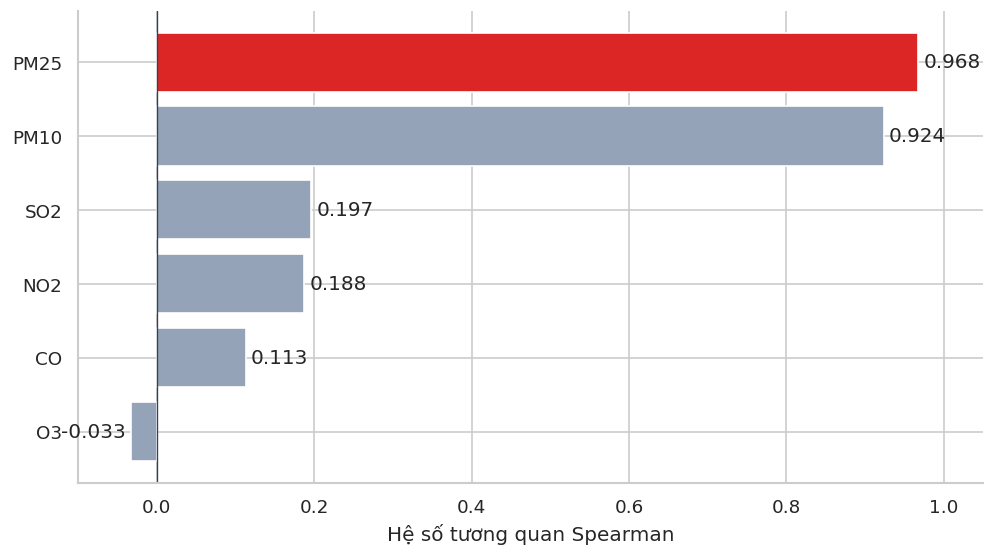

In [18]:
aqi_corr = (
    df_clean[["AQI", *pollutant_cols]]
    .corr(method="spearman")["AQI"]
    .drop("AQI")
    .sort_values()
)

fig, ax = plt.subplots(figsize=(8.5, 4.8))
colors = ["#dc2626" if name == "PM25" else "#94a3b8" for name in aqi_corr.index]
bars = ax.barh(aqi_corr.index, aqi_corr.values, color=colors)
ax.axvline(0, color="#334155", linewidth=0.8)
ax.set_xlim(min(-0.1, aqi_corr.min() - 0.05), 1.05)
# ax.set_title("Tương quan Spearman giữa AQI và các chất ô nhiễm")
ax.set_xlabel("Hệ số tương quan Spearman")
ax.set_ylabel("")
ax.bar_label(bars, labels=[f"{value:.3f}" for value in aqi_corr.values], padding=3)
plt.tight_layout()
plt.show()

pm_time = df_clean.set_index("Local Time")["PM25"].sort_index()
acf_1h = pm_time.autocorr(lag=1)


## 7. Phân bố, mức độ biến động và các giá trị PM2.5 cao

,Chỉ tiêu,Giá trị,Đơn vị
0,Trung bình,43.33,µg/m³
1,Trung vị,34.40,µg/m³
2,Độ lệch chuẩn,32.61,µg/m³
3,Hệ số lệch,2.31,-
4,Nhỏ nhất,1.00,µg/m³
5,Lớn nhất,400.00,µg/m³


C:\Users\hungd\AppData\Local\Temp\ipykernel_20236\1258871126.py:33: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend()


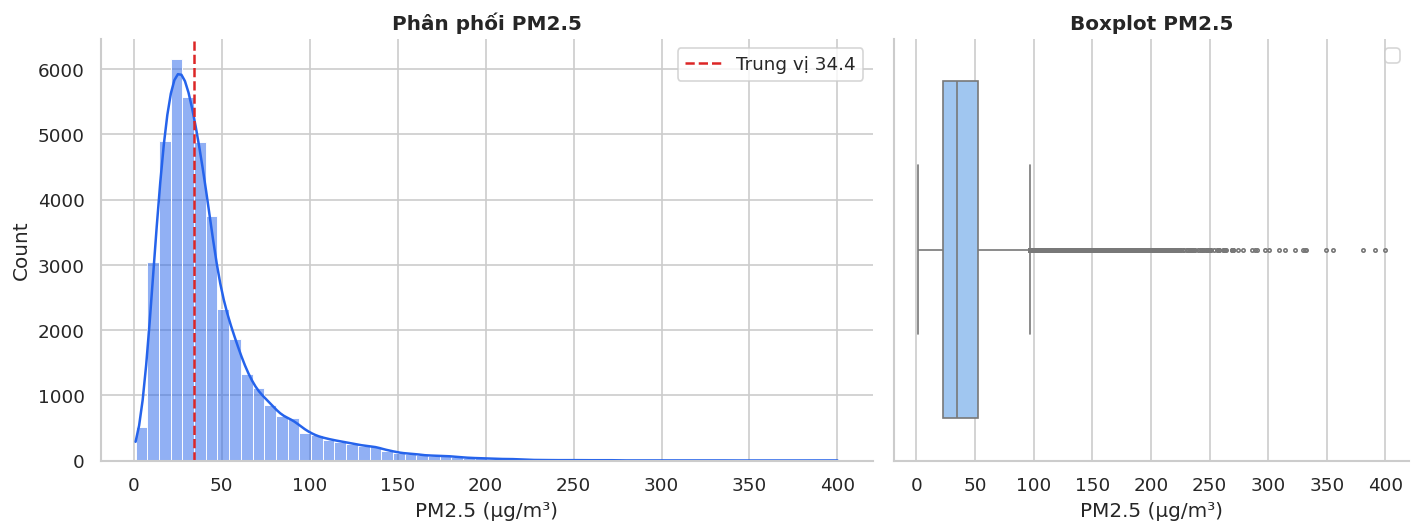

In [19]:
pm25 = df_clean["PM25"].dropna()
quantiles = pm25.quantile([0.01, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99])
iqr = quantiles.loc[0.75] - quantiles.loc[0.25]
upper_fence = quantiles.loc[0.75] + 1.5 * iqr

pm25_summary = pd.DataFrame({
    "Chỉ tiêu": [
         "Trung bình", "Trung vị", "Độ lệch chuẩn", "Hệ số lệch",
         "Nhỏ nhất", "Lớn nhất", 
    ],
    "Giá trị": [
        pm25.mean(), pm25.median(), pm25.std(), pm25.skew(),
        
        pm25.min(), pm25.max(),
    ],
    "Đơn vị": [
         "µg/m³", "µg/m³", "µg/m³",
        "-", "µg/m³", "µg/m³"
    ],
})
display(pm25_summary.style.format({"Giá trị": "{:,.2f}"}))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), gridspec_kw={"width_ratios": [3, 2]})
sns.histplot(pm25, bins=60, kde=True, color="#2563eb", ax=axes[0])
axes[0].axvline(pm25.median(), color="#dc2626", linestyle="--", label=f"Trung vị {pm25.median():.1f}")
axes[0].set_title("Phân phối PM2.5")
axes[0].set_xlabel("PM2.5 (µg/m³)")

axes[0].legend()
sns.boxplot(x=pm25, color="#93c5fd", fliersize=2, ax=axes[1])
axes[1].set_title("Boxplot PM2.5")
axes[1].set_xlabel("PM2.5 (µg/m³)")
axes[1].legend()
plt.tight_layout()
plt.show()




**10 thời điểm theo giờ cao nhất**

,Local Time,PM25,AQI,PM10,Temperature,Relative Humidity,Precipitation,Wind Speed,WasMissingTimestamp,HadMissingMeasurement
0,2024-02-07 19:00:00,400.00,289.00,400.00,14.60,94.00,0.00,3.00,False,False
1,2025-03-20 23:00:00,390.90,500.00,452.60,19.10,63.00,0.00,1.33,False,False
2,2025-03-20 22:00:00,380.90,399.00,441.70,20.10,61.00,0.00,2.00,False,False
3,2023-12-14 03:00:00,355.50,279.00,368.00,23.00,88.00,0.00,1.00,False,False
4,2022-04-08 04:00:00,349.60,500.00,485.30,19.50,88.00,0.00,0.80,False,False
5,2022-04-08 03:00:00,332.40,478.00,487.50,20.30,83.00,0.00,0.80,False,False
6,2025-01-02 23:00:00,331.80,455.00,342.30,18.90,74.00,0.00,1.60,False,False
7,2022-04-08 05:00:00,329.40,500.00,483.20,19.40,91.00,0.00,1.20,False,False
8,2025-01-02 22:00:00,322.60,398.00,332.80,19.40,71.00,0.00,1.20,False,False
9,2022-04-08 02:00:00,314.20,442.00,489.70,21.20,78.00,0.00,1.20,False,False


**10 ngày có trung bình PM2.5 cao nhất**

,Local Time,PM2.5 trung bình ngày
0,2025-01-02,170.86
1,2025-01-20,167.72
2,2025-12-12,165.70
3,2022-04-08,163.05
4,2024-02-01,159.42
5,2023-11-29,158.47
6,2023-11-19,153.53
7,2022-04-07,152.82
8,2025-01-03,149.05
9,2024-12-25,146.37


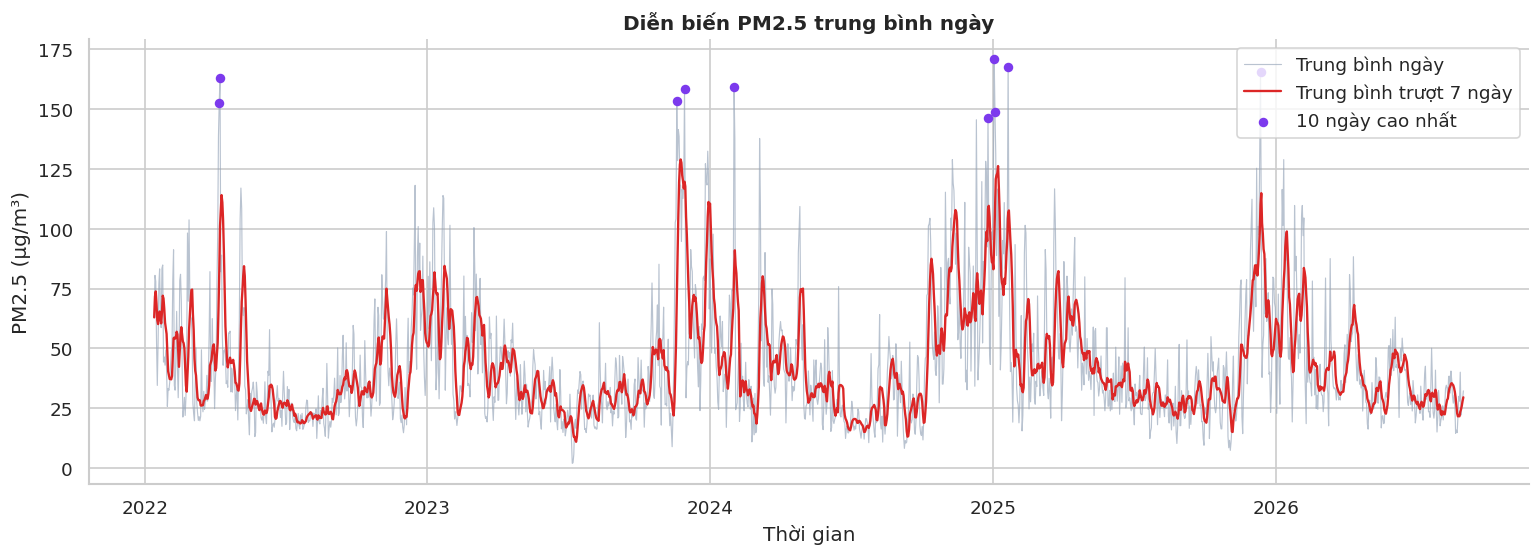

In [20]:
daily_pm25 = pm_time.resample("D").mean()
rolling_7d = daily_pm25.rolling(7, min_periods=1).mean()
top_hourly = df_clean.nlargest(10, "PM25")[[
    "Local Time", "PM25", "AQI", "PM10", "Temperature",
    "Relative Humidity", "Precipitation", "Wind Speed",
    "WasMissingTimestamp", "HadMissingMeasurement"
]].reset_index(drop=True)
top_daily = daily_pm25.nlargest(10).rename("PM2.5 trung bình ngày").reset_index()

display(Markdown("**10 thời điểm theo giờ cao nhất**"))
display(top_hourly)
display(Markdown("**10 ngày có trung bình PM2.5 cao nhất**"))
display(top_daily)

fig, ax = plt.subplots(figsize=(13, 4.8))
ax.plot(daily_pm25.index, daily_pm25, color="#94a3b8", linewidth=0.7, alpha=0.65, label="Trung bình ngày")
ax.plot(rolling_7d.index, rolling_7d, color="#dc2626", linewidth=1.4, label="Trung bình trượt 7 ngày")
ax.scatter(top_daily["Local Time"], top_daily["PM2.5 trung bình ngày"], color="#7c3aed", s=22, zorder=3, label="10 ngày cao nhất")
ax.set_title("Diễn biến PM2.5 trung bình ngày")
ax.set_xlabel("Thời gian")
ax.set_ylabel("PM2.5 (µg/m³)")
ax.legend()
plt.tight_layout()
plt.show()

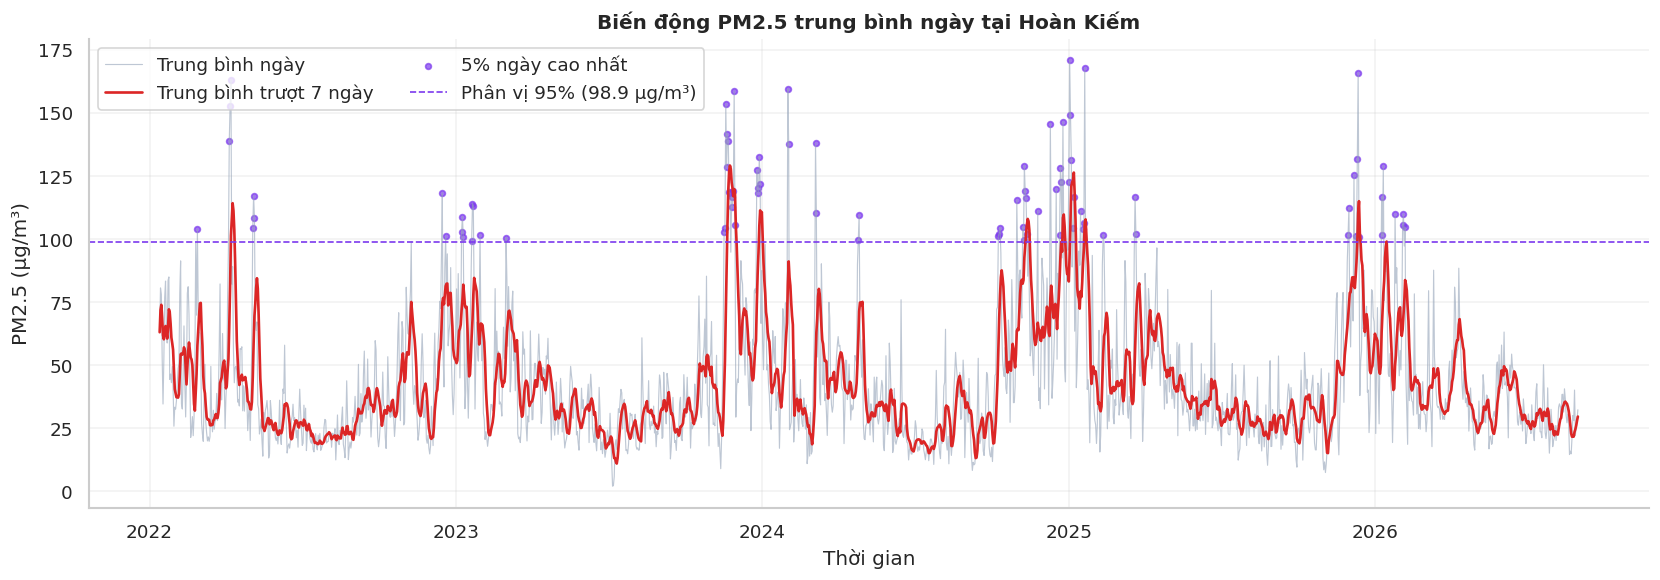

In [133]:
# Chuỗi PM2.5 theo thời gian
pm25_time = (
    df_clean
    .set_index("Local Time")["PM25"]
    .sort_index()
)

# Trung bình ngày và xu hướng 7 ngày
daily_pm25 = pm25_time.resample("D").mean()
rolling_7d = daily_pm25.rolling(
    window=7,
    min_periods=1
).mean()

# Ngưỡng xác định 5% số ngày có PM2.5 cao nhất
p95 = daily_pm25.quantile(0.95)
high_days = daily_pm25[daily_pm25 >= p95]

fig, ax = plt.subplots(figsize=(14, 5))

# Biến động từng ngày
ax.plot(
    daily_pm25.index,
    daily_pm25,
    color="#94a3b8",
    linewidth=0.7,
    alpha=0.6,
    label="Trung bình ngày"
)

# Xu hướng chính
ax.plot(
    rolling_7d.index,
    rolling_7d,
    color="#dc2626",
    linewidth=1.6,
    label="Trung bình trượt 7 ngày"
)

# Các ngày PM2.5 cao
ax.scatter(
    high_days.index,
    high_days,
    color="#7c3aed",
    s=12,
    alpha=0.7,
    label="5% ngày cao nhất"
)

# Đường phân vị 95%
ax.axhline(
    p95,
    color="#7c3aed",
    linestyle="--",
    linewidth=1,
    label=f"Phân vị 95% ({p95:.1f} µg/m³)"
)

ax.set_title("Biến động PM2.5 trung bình ngày tại Hoàn Kiếm")
ax.set_xlabel("Thời gian")
ax.set_ylabel("PM2.5 (µg/m³)")
ax.legend(ncol=2)
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

## 8. PM2.5 theo giờ, tháng, mùa và năm

**Tóm tắt theo năm**

,count,mean,median,std,max
Year,,,,,
2022,8472,40.10,31.30,31.02,349.60
2023,8760,43.70,34.40,33.75,355.50
2024,8784,45.40,36.40,35.68,400.00
2025,8760,45.91,36.00,33.82,390.90
2026,5832,40.50,35.00,24.86,214.00


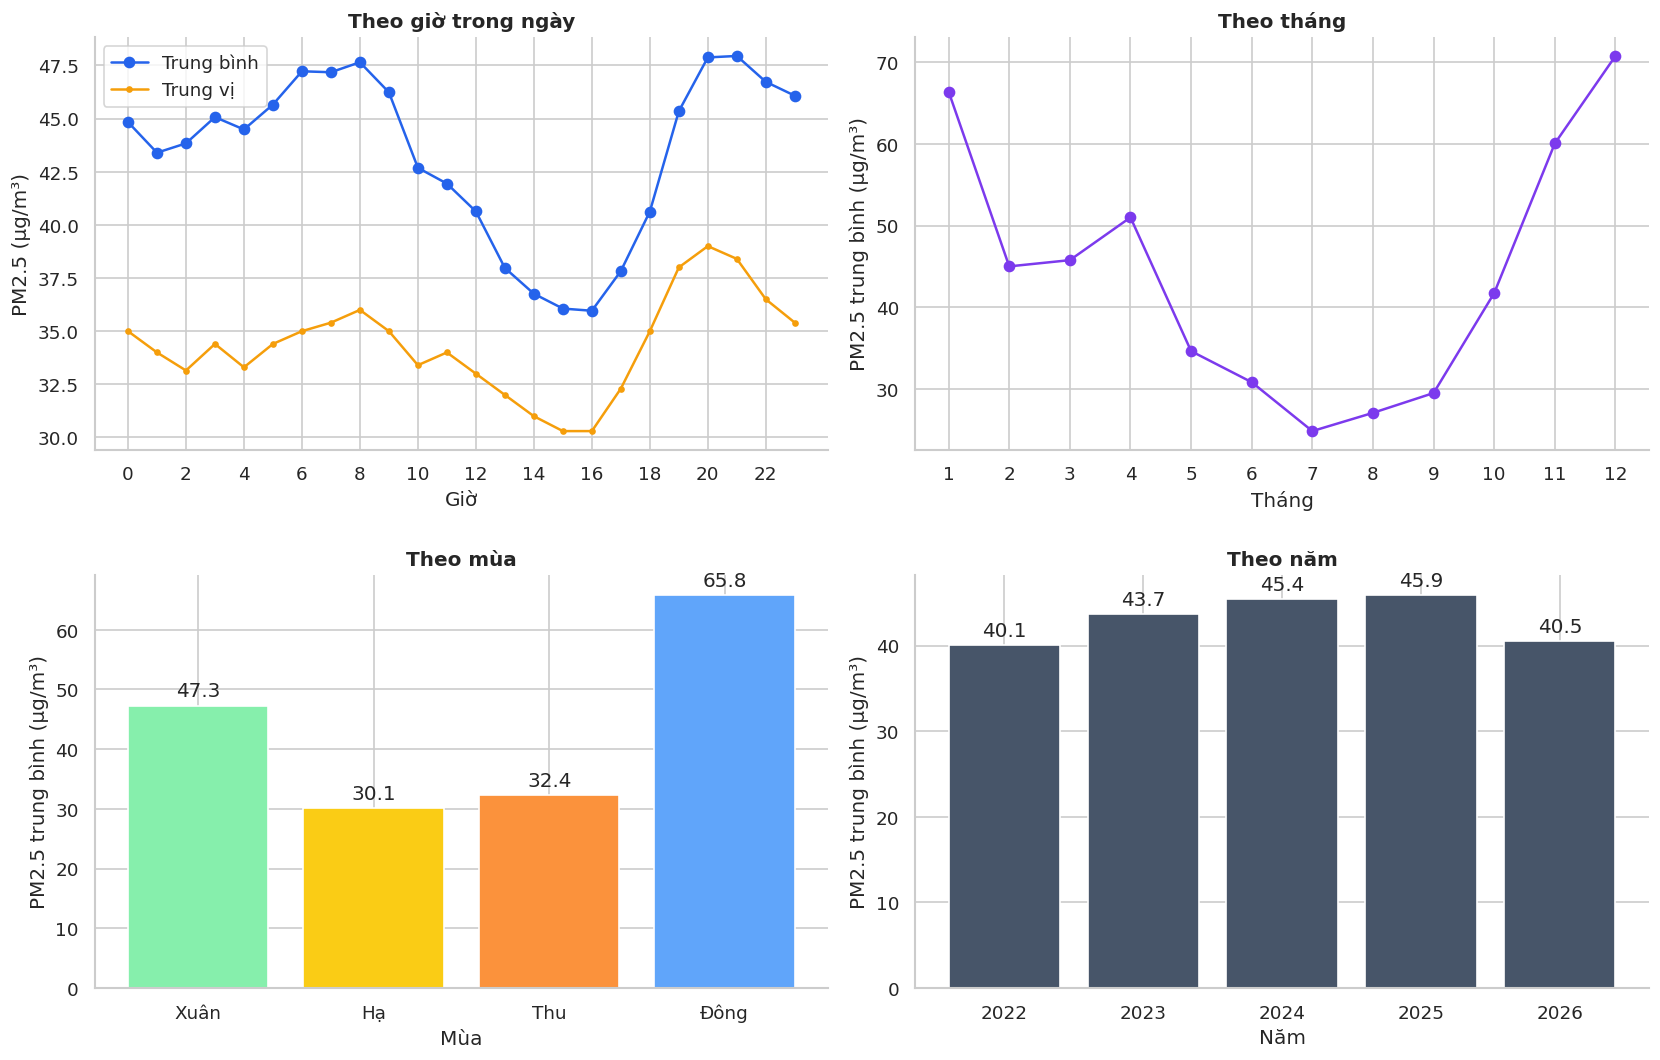

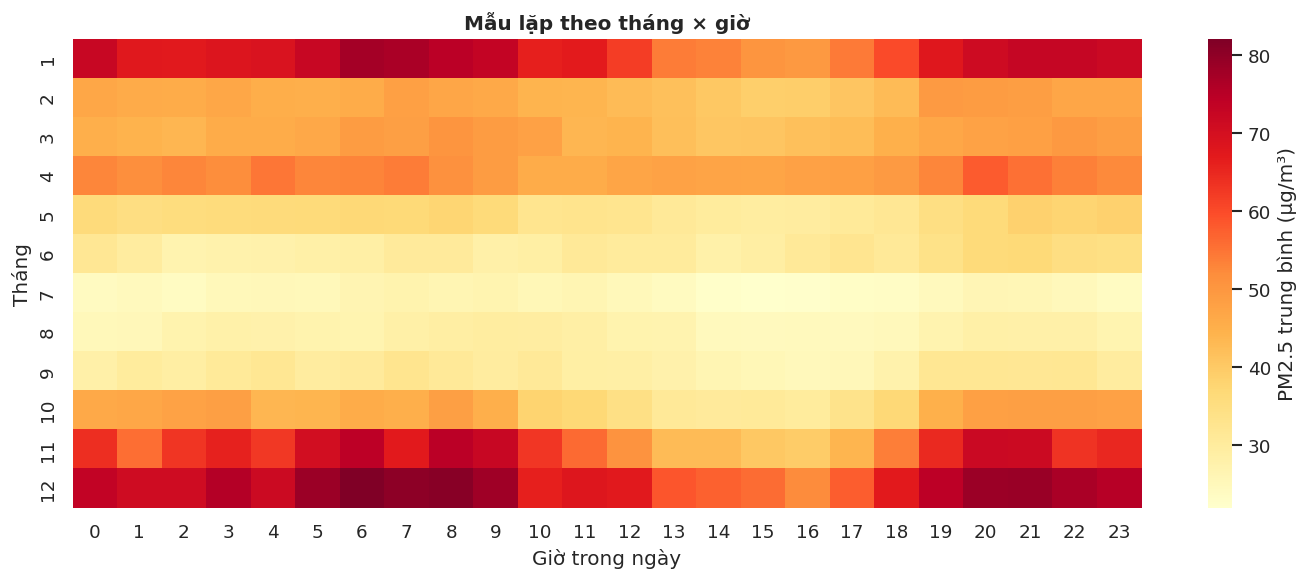

PM2.5 trung bình cao nhất lúc **21:00** (**47.94 µg/m³**) và thấp nhất lúc **16:00** (**35.96 µg/m³**). Tháng cao nhất là tháng **12**, thấp nhất là tháng **7**.

In [21]:
hourly = df_clean.groupby("Hour", observed=True)["PM25"].agg(["mean", "median", "std"])
monthly = df_clean.groupby("Month", observed=True)["PM25"].agg(["mean", "median", "std"])
seasonal = df_clean.groupby("Season", observed=True)["PM25"].agg(["mean", "median", "std"])
yearly = df_clean.groupby("Year", observed=True)["PM25"].agg(["count", "mean", "median", "std", "max"])
month_hour = df_clean.pivot_table(index="Month", columns="Hour", values="PM25", aggfunc="mean")

display(Markdown("**Tóm tắt theo năm**"))
display(yearly)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes[0, 0].plot(hourly.index, hourly["mean"], marker="o", color="#2563eb", label="Trung bình")
axes[0, 0].plot(hourly.index, hourly["median"], marker=".", color="#f59e0b", label="Trung vị")
axes[0, 0].set_xticks(range(0, 24, 2))
axes[0, 0].set_title("Theo giờ trong ngày")
axes[0, 0].set_xlabel("Giờ")
axes[0, 0].set_ylabel("PM2.5 (µg/m³)")
axes[0, 0].legend()

axes[0, 1].plot(monthly.index, monthly["mean"], marker="o", color="#7c3aed")
axes[0, 1].set_xticks(range(1, 13))
axes[0, 1].set_title("Theo tháng")
axes[0, 1].set_xlabel("Tháng")
axes[0, 1].set_ylabel("PM2.5 trung bình (µg/m³)")

season_bars = axes[1, 0].bar(seasonal.index.astype(str), seasonal["mean"], color=["#86efac", "#facc15", "#fb923c", "#60a5fa"])
axes[1, 0].bar_label(season_bars, fmt="%.1f", padding=3)
axes[1, 0].set_title("Theo mùa")
axes[1, 0].set_xlabel("Mùa")
axes[1, 0].set_ylabel("PM2.5 trung bình (µg/m³)")

year_bars = axes[1, 1].bar(yearly.index.astype(str), yearly["mean"], color="#475569")
axes[1, 1].bar_label(year_bars, fmt="%.1f", padding=3)
axes[1, 1].set_title("Theo năm")
axes[1, 1].set_xlabel("Năm")
axes[1, 1].set_ylabel("PM2.5 trung bình (µg/m³)")
plt.tight_layout(h_pad=2)
plt.show()

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(month_hour, cmap="YlOrRd", ax=ax, cbar_kws={"label": "PM2.5 trung bình (µg/m³)"})
ax.set_title("Mẫu lặp theo tháng × giờ")
ax.set_xlabel("Giờ trong ngày")
ax.set_ylabel("Tháng")
plt.tight_layout()
plt.show()

highest_hour = hourly["mean"].idxmax()
lowest_hour = hourly["mean"].idxmin()
highest_month = monthly["mean"].idxmax()
lowest_month = monthly["mean"].idxmin()
display(Markdown(
    f"PM2.5 trung bình cao nhất lúc **{highest_hour}:00** (**{hourly.loc[highest_hour, 'mean']:.2f} µg/m³**) "
    f"và thấp nhất lúc **{lowest_hour}:00** (**{hourly.loc[lowest_hour, 'mean']:.2f} µg/m³**). "
    f"Tháng cao nhất là tháng **{highest_month}**, thấp nhất là tháng **{lowest_month}**."
))

In [129]:
# lag_hours = [1, 3, 6, 12, 24, 48, 72, 168]
# lag_corr = pd.Series({lag: pm_time.autocorr(lag=lag) for lag in lag_hours}, name="Tự tương quan")
# display(lag_corr.to_frame())

# fig, ax = plt.subplots(figsize=(9, 4))
# ax.plot(lag_corr.index, lag_corr.values, marker="o", color="#0f766e")
# ax.axhline(0, color="#334155", linewidth=0.8)
# ax.set_xticks(lag_hours)
# ax.set_title("Tự tương quan PM2.5 theo độ trễ")
# ax.set_xlabel("Độ trễ (giờ)")
# ax.set_ylabel("Hệ số tự tương quan")
# plt.tight_layout()
# plt.show()

# display(Markdown(
#     f"Tự tương quan đạt **{lag_corr.loc[1]:.3f}** ở trễ 1 giờ, **{lag_corr.loc[24]:.3f}** ở trễ 24 giờ "
#     f"và **{lag_corr.loc[168]:.3f}** ở trễ 168 giờ. Chuỗi có quán tính và mẫu lặp theo ngày/tuần."
# ))

## 9. Liên hệ giữa PM2.5, các chất ô nhiễm và khí tượng

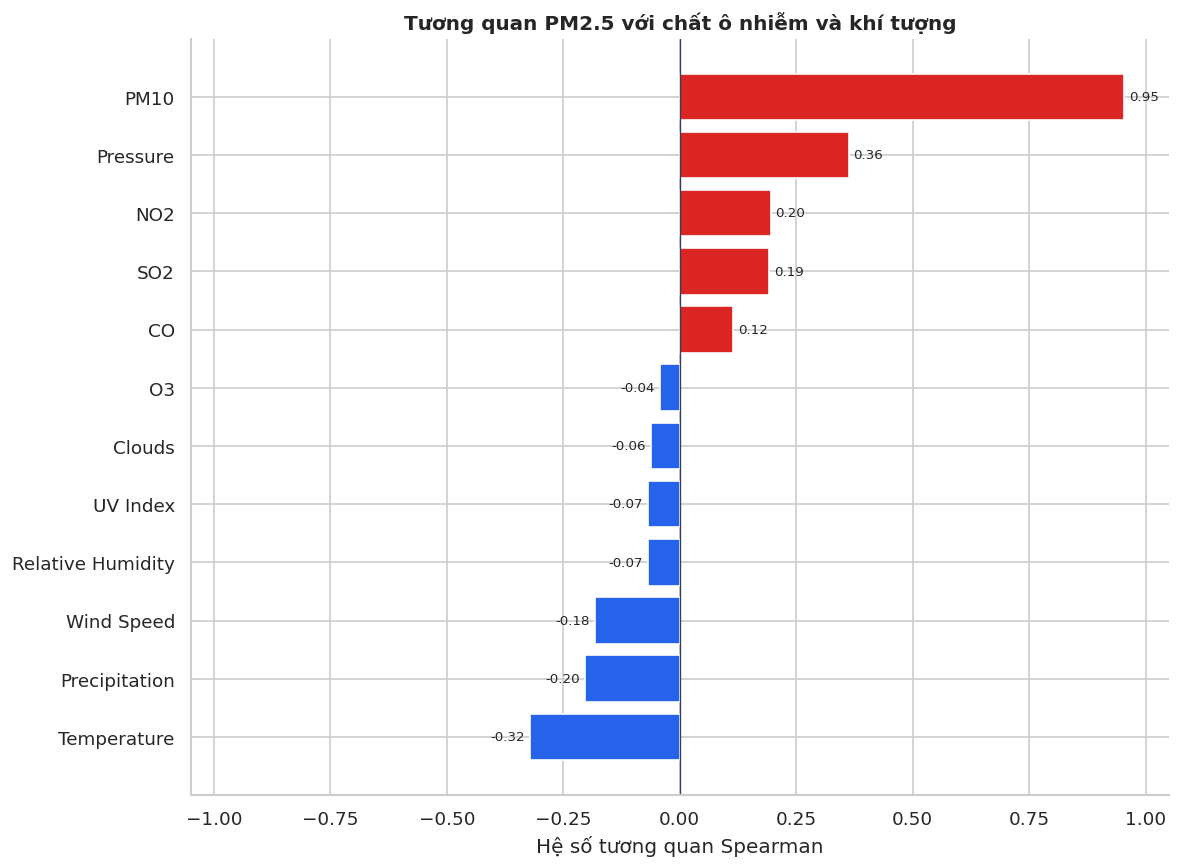

,Spearman với PM2.5
Temperature,-0.32
Precipitation,-0.20
Wind Speed,-0.18
Relative Humidity,-0.07
UV Index,-0.07
Clouds,-0.06
O3,-0.04
CO,0.12
SO2,0.19
NO2,0.20


PM10 có tương quan mạnh nhất với PM2.5 (**0.953**). Áp suất tương quan dương (**0.362**), trong khi nhiệt độ (**-0.321**), mưa (**-0.204**) và tốc độ gió (**-0.183**) tương quan âm.  
*Lưu ý:* `Wind Direction` là góc tuần hoàn (0° gần 360°), nên tương quan Spearman trên số độ chỉ mang tính mô tả; khi lập mô hình nên mã hóa thành sin/cos.

In [128]:
weather_corr_cols = [
    "Temperature", "Relative Humidity", "Precipitation", "Clouds",
    "Pressure", "UV Index", "Wind Speed", "Wind Direction",
    "Solar Radiation"
]
corr_candidates = ["CO", "NO2", "O3", "PM10", "SO2", *weather_corr_cols]
overall_corr = (
    df_clean[["PM25", *corr_candidates]]
    .corr(method="spearman")["PM25"]
    .drop("PM25")
    .sort_values()
)

fig, ax = plt.subplots(figsize=(10, 7.4))
bar_colors = [
    "#dc2626" if value >= 0 else "#2563eb"
    for name, value in overall_corr.items()
]
bars = ax.barh(overall_corr.index, overall_corr.values, color=bar_colors)
ax.axvline(0, color="#334155", linewidth=0.8)
ax.set_xlim(-1.05, 1.05)
ax.set_title("Tương quan PM2.5 với chất ô nhiễm và khí tượng")
ax.set_xlabel("Hệ số tương quan Spearman")
ax.set_ylabel("")
ax.bar_label(bars, labels=[f"{value:.2f}" for value in overall_corr.values], padding=3, fontsize=8)
plt.tight_layout()
plt.show()

display(overall_corr.rename("Spearman với PM2.5").to_frame())
display(Markdown(
    f"PM10 có tương quan mạnh nhất với PM2.5 (**{overall_corr['PM10']:.3f}**). "
    f"Áp suất tương quan dương (**{overall_corr['Pressure']:.3f}**), trong khi nhiệt độ "
    f"(**{overall_corr['Temperature']:.3f}**), mưa (**{overall_corr['Precipitation']:.3f}**) và "
    f"tốc độ gió (**{overall_corr['Wind Speed']:.3f}**) tương quan âm.  \n"
    "*Lưu ý:* `Wind Direction` là góc tuần hoàn (0° gần 360°), nên tương quan Spearman "
    "trên số độ chỉ mang tính mô tả; khi lập mô hình nên mã hóa thành sin/cos."
))

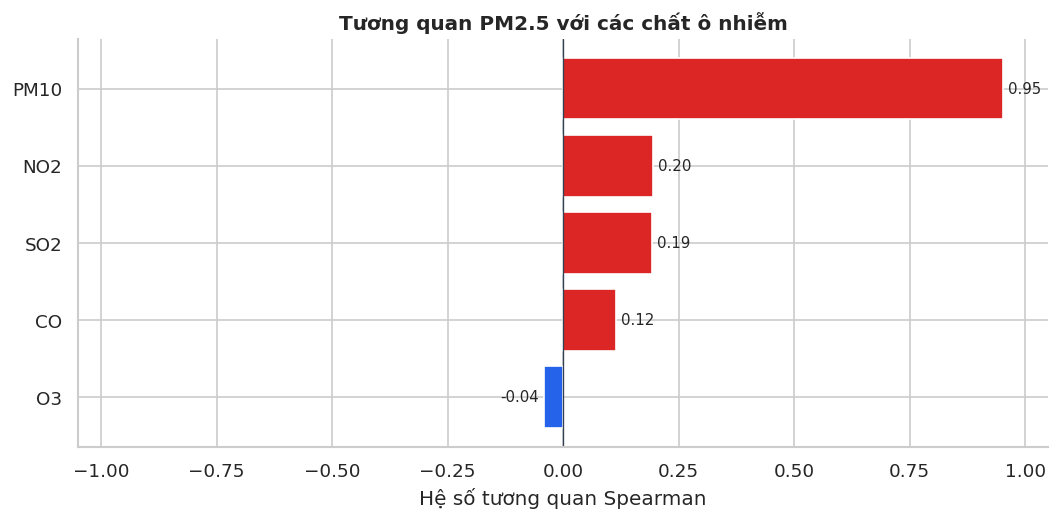

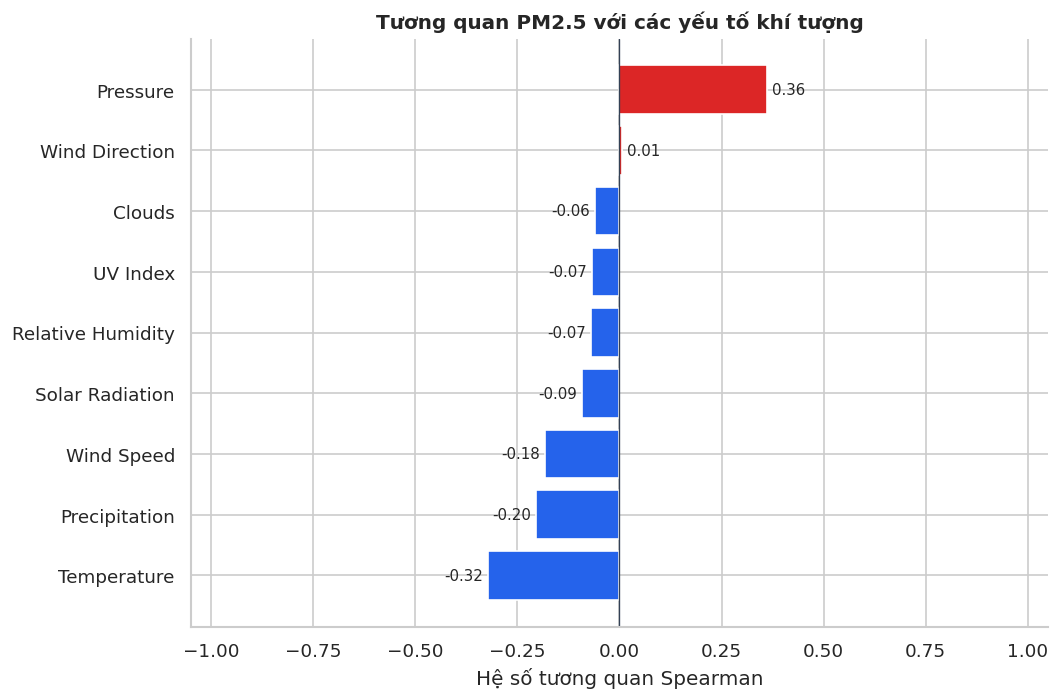

In [132]:
pollutant_cols = ["CO", "NO2", "O3", "PM10", "SO2"]

weather_cols = [
    "Temperature",
    "Relative Humidity",
    "Precipitation",
    "Clouds",
    "Pressure",
    "UV Index",
    "Wind Speed",
    "Wind Direction",
    "Solar Radiation"
]


def plot_pm25_correlation(columns, title, figsize):
    corr = (
        df_clean[["PM25"] + columns]
        .corr(method="spearman")["PM25"]
        .drop("PM25")
        .sort_values()
    )

    fig, ax = plt.subplots(figsize=figsize)

    colors = [
        "#dc2626" if value >= 0 else "#2563eb"
        for value in corr.values
    ]

    bars = ax.barh(
        corr.index,
        corr.values,
        color=colors
    )

    ax.axvline(0, color="#334155", linewidth=0.8)
    ax.set_xlim(-1.05, 1.05)
    ax.set_title(title)
    ax.set_xlabel("Hệ số tương quan Spearman")
    ax.set_ylabel("")

    ax.bar_label(
        bars,
        labels=[f"{value:.2f}" for value in corr.values],
        padding=3,
        fontsize=9
    )

    plt.tight_layout()
    plt.show()

    return corr

pollutant_corr = plot_pm25_correlation(
    columns=pollutant_cols,
    title="Tương quan PM2.5 với các chất ô nhiễm",
    figsize=(9, 4.5)
)

weather_corr = plot_pm25_correlation(
    columns=weather_cols,
    title="Tương quan PM2.5 với các yếu tố khí tượng",
    figsize=(9, 6)
)

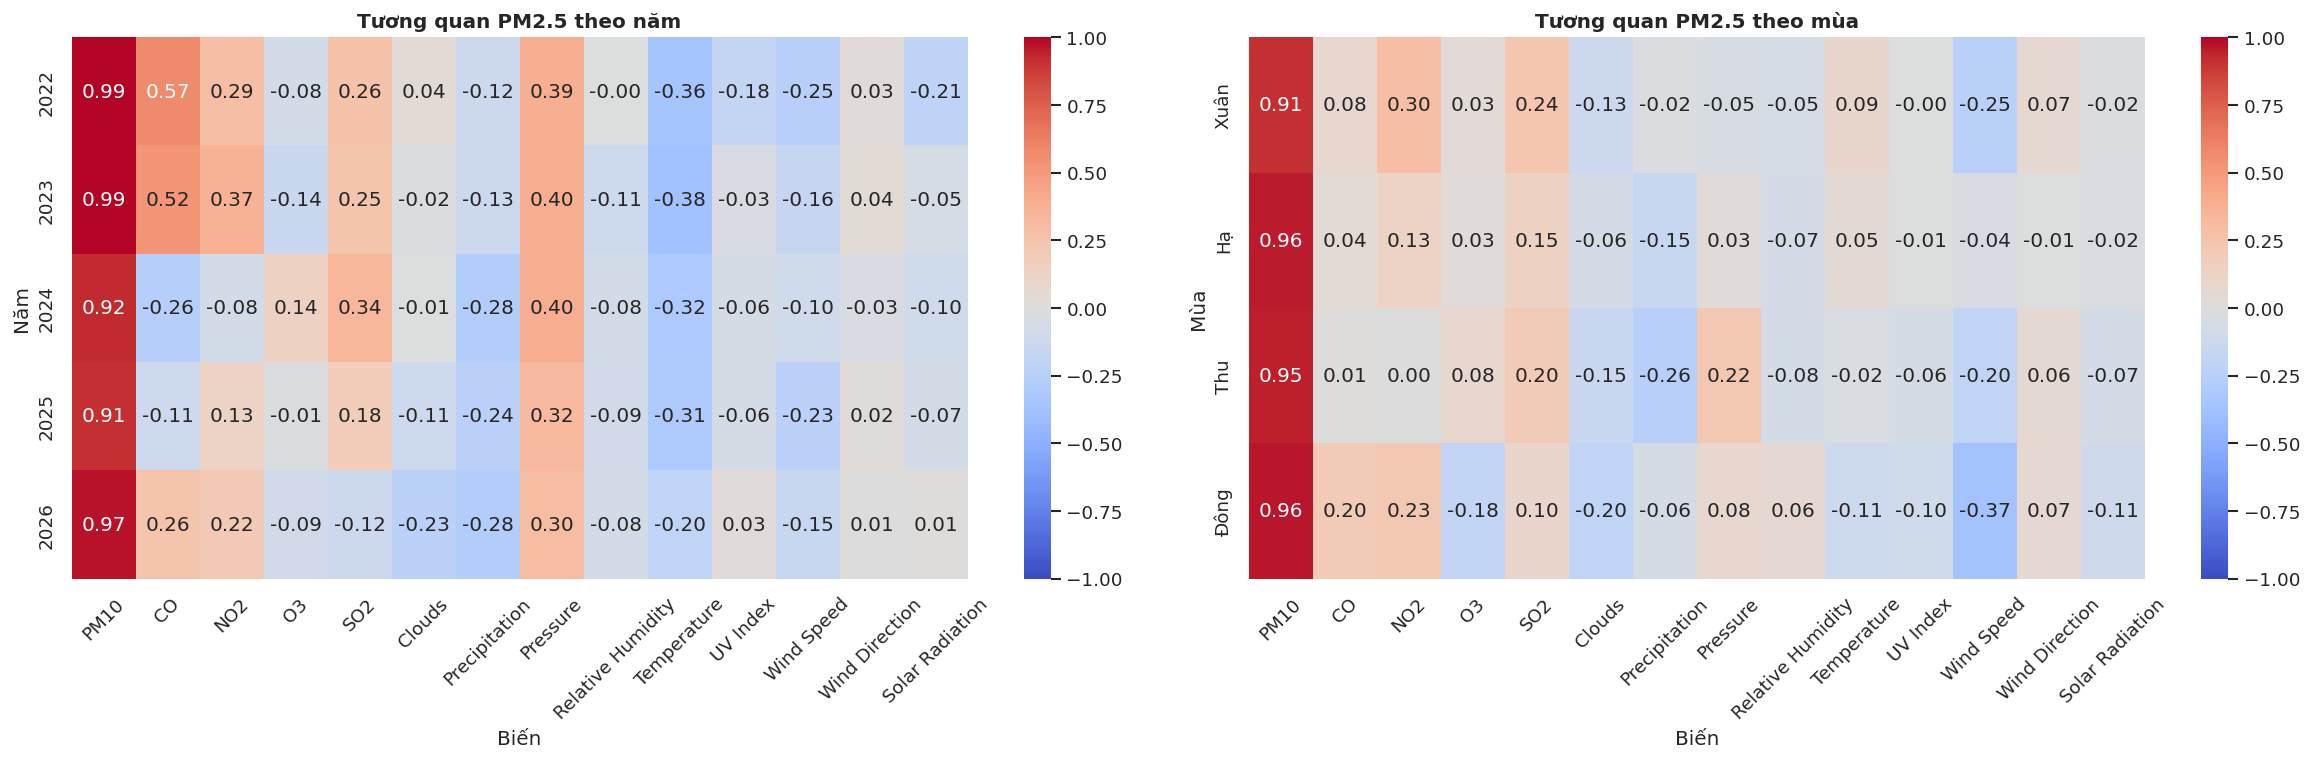

Một số tương quan thay đổi đáng kể theo năm và mùa. Vì vậy mô hình cần được đánh giá theo rolling/walk-forward và theo từng giai đoạn, thay vì giả định toàn bộ chuỗi có cùng một chế độ.

In [24]:
period_weather_cols = [
    "Temperature", "Relative Humidity", "Precipitation", "Clouds",
    "Pressure", "UV Index", "Wind Speed", "Wind Direction",
    "Solar Radiation"
]
period_features = ["PM10", "CO", "NO2", "O3", "SO2", *period_weather_cols]
by_year_corr = pd.DataFrame({
    year: group[["PM25", *period_features]].corr(method="spearman")["PM25"].drop("PM25")
    for year, group in df_clean.groupby("Year")
}).T
by_season_corr = pd.DataFrame({
    str(season): group[["PM25", *period_features]].corr(method="spearman")["PM25"].drop("PM25")
    for season, group in df_clean.groupby("Season", observed=True)
}).T.reindex(season_order)

fig, axes = plt.subplots(1, 2, figsize=(20, 6.5))
sns.heatmap(by_year_corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1, ax=axes[0])
axes[0].set_title("Tương quan PM2.5 theo năm")
axes[0].set_xlabel("Biến")
axes[0].set_ylabel("Năm")
axes[0].tick_params(axis="x", rotation=45)
sns.heatmap(by_season_corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title("Tương quan PM2.5 theo mùa")
axes[1].set_xlabel("Biến")
axes[1].set_ylabel("Mùa")
axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

display(Markdown(
    "Một số tương quan thay đổi đáng kể theo năm và mùa. Vì vậy mô hình cần được đánh giá theo "
    "rolling/walk-forward và theo từng giai đoạn, thay vì giả định toàn bộ chuỗi có cùng một chế độ."
))

## 10. Mức độ sẵn sàng cho dự báo PM2.5

In [25]:
readiness = pd.DataFrame([
    ("Dữ liệu raw", "Có vấn đề để làm sạch", "Thiếu giá trị, 8 timestamp lặp và 18 giờ bị thiếu"),
    ("Sau làm sạch", "Đạt cho EDA", f"{len(df_clean):,} giờ liên tục, không NA/trùng/gap"),
    ("Cờ chất lượng", "Đã bổ sung", "WasMissingTimestamp, HadMissingMeasurement, WasImputed, ImputedCellCount"),
    ("Tín hiệu dự báo", "Tốt", f"ACF 1 giờ = {lag_corr.loc[1]:.3f}; ACF 24 giờ = {lag_corr.loc[24]:.3f}"),
    ("Mùa vụ", "Tốt cho mô hình", "Có mẫu giờ, tháng và mùa rõ"),
    ("Phân phối/đỉnh", "Cần xử lý", f"Skew = {pm25.skew():.2f}; P99 = {quantiles.loc[0.99]:.1f} µg/m³"),
    ("Nguồn gốc dữ liệu", "Chưa đầy đủ", "CSV không ghi nguồn, phiên bản và quy trình tạo"),
], columns=["Tiêu chí", "Đánh giá", "Bằng chứng"])
display(readiness)

display(Markdown(
    '''
### Chuẩn bị trước khi huấn luyện

1. Chia train/validation/test theo thời gian, không shuffle.
2. Học quy tắc điền thiếu chỉ trên tập train; không dùng toàn bộ chuỗi như bước EDA.
3. Tạo lag/rolling từ `PM25.shift(1)` để tránh rò rỉ dữ liệu.
4. Không dùng AQI cùng thời điểm làm feature dự báo PM2.5.
5. Xử lý phân phối lệch và đỉnh bằng biến đổi mục tiêu, loss bền vững hoặc trọng số cho đỉnh.
6. Dùng walk-forward validation và báo cáo sai số riêng theo mùa, năm và nhóm PM2.5 cao.
7. Bổ sung metadata nguồn và quy trình xử lý nếu có thể truy lại.
'''
))

,Tiêu chí,Đánh giá,Bằng chứng
0,Dữ liệu raw,Có vấn đề để làm sạch,"Thiếu giá trị, 8 timestamp lặp và 18 giờ bị thiếu"
1,Sau làm sạch,Đạt cho EDA,"40,608 giờ liên tục, không NA/trùng/gap"
2,Cờ chất lượng,Đã bổ sung,"WasMissingTimestamp, HadMissingMeasurement, Wa..."
3,Tín hiệu dự báo,Tốt,ACF 1 giờ = 0.881; ACF 24 giờ = 0.589
4,Mùa vụ,Tốt cho mô hình,"Có mẫu giờ, tháng và mùa rõ"
5,Phân phối/đỉnh,Cần xử lý,Skew = 2.31; P99 = 168.6 µg/m³
6,Nguồn gốc dữ liệu,Chưa đầy đủ,"CSV không ghi nguồn, phiên bản và quy trình tạo"



### Chuẩn bị trước khi huấn luyện

1. Chia train/validation/test theo thời gian, không shuffle.
2. Học quy tắc điền thiếu chỉ trên tập train; không dùng toàn bộ chuỗi như bước EDA.
3. Tạo lag/rolling từ `PM25.shift(1)` để tránh rò rỉ dữ liệu.
4. Không dùng AQI cùng thời điểm làm feature dự báo PM2.5.
5. Xử lý phân phối lệch và đỉnh bằng biến đổi mục tiêu, loss bền vững hoặc trọng số cho đỉnh.
6. Dùng walk-forward validation và báo cáo sai số riêng theo mùa, năm và nhóm PM2.5 cao.
7. Bổ sung metadata nguồn và quy trình xử lý nếu có thể truy lại.


## Kết luận theo bảy câu hỏi

1. `datadone.csv` chứa 40.598 bản ghi và 21 biến về thời gian, địa điểm, AQI, chất ô nhiễm và khí tượng từ 13/01/2022 đến 31/08/2026. CSV không đủ metadata để xác định chắc chắn quy trình tạo.
2. PM2.5 là mục tiêu hợp lý vì liên hệ rất mạnh với AQI, có biến động đáng kể và tự tương quan cao.
3. PM2.5 lệch phải, có nhiều đỉnh; không nên xóa outlier tự động.
4. PM2.5 có mẫu lặp theo giờ, tháng, mùa và năm; cao hơn vào sáng/tối và mùa lạnh.
5. PM10 liên hệ dương mạnh nhất trong các biến đầu vào; nhiệt độ, mưa và gió thường liên hệ âm. Quan hệ thay đổi theo giai đoạn.
6. Raw có 74 giá trị thiếu ở CO/NO2/O3/SO2, 2 ở PM10/PM25, 8 timestamp lặp và 18 giờ bị thiếu. Notebook đã xử lý nhưng giữ cờ chất lượng.
7. Dữ liệu sau làm sạch dùng được cho EDA và thử nghiệm dự báo. Trước mô hình chính thức cần tách theo thời gian, chống leakage, học imputation trên train và đánh giá drift/đỉnh.